# ReefSafe: High-Precision Predictive Intelligence for Sustainable Marine Tourism
**DOSM Datathon 2026 - Machine Learning and Artificial Intelligence for Sustainable Tourism**

ReefSafe answers four decision-focused objectives:

1. **Identify Associated Factors:** Examine lagged associations between reef change, regional thermal stress, water-quality indicators, and documented local disturbances.
2. **Compare Available Stressor Evidence:** Quantify observed thermal and local-pressure signals across monitoring units.
3. **Prioritise Field Verification:** Accurately predict coral cover trajectory and rank monitoring units for targeted ranger intervention using high-precision predictive modeling.
4. **Frame Conservation with Economic Context:** Use the published RM8.7 billion annual benchmark for six evaluated Malaysian marine-park archipelagos during 2011-2015 as macroeconomic context for conservation planning.

> **Decision boundary:** ReefSafe delivers high-precision predictive modeling while respecting scientific data boundaries. It does not calculate legal visitor capacity, prove causality without vessel-level tracking, estimate island revenue, or guarantee an intervention outcome.


---
## Phase 1: Data Provenance

| Evidence | Publisher | Scope | Use |
|---|---|---|---|
| Reef surveys | Reef Check Malaysia | 6,381 site-year observations (2012-2025) | Ecological condition and documented impact mentions |
| Thermal context | NOAA Coral Reef Watch | Five regional virtual stations | Supporting regional heat signal, subject to DOSM eligibility confirmation |
| Marine-park visitors | Department of Marine Park Malaysia / data.gov.my | Five state datasets, 2000-2017; every row matches the published CSV | State context only; never allocated to monitoring units |
| Island arrivals | Sabah Parks; Terengganu State Tourism Department | 11 monitoring units, 2024 | Measured arrivals for economic context only |
| Total Economic Value | Department of Marine Park Malaysia | Six evaluated archipelagos, 2011-2015 | Historical literature benchmark only |

The primary economic source is `TOTAL ECONOMIC VALUE OF MARINE BIODIVERSITY.pdf`. Its component values are transcribed with source pages in `dmpm_tev_2011_2015.csv`.


In [1]:
import csv
import json
import runpy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.economic_valuation import load_dmpm_tev
from scripts.train_models import FEATURES, main as train_models

get_ipython().run_line_magic("matplotlib", "inline")

print(f"Repository root: {ROOT}")


Repository root: C:\Users\Chee\Documents\dosm2026


---
## Phase 2: Preprocessing and Master Dataset Pipeline

This section implements the transparent, reproducible data integration pipeline that builds `master_reef_tourism_dataset.csv` from raw structured sources:
1. **Reef Check Survey Observations:** Loaded from the verified `model_ready` sheet of `ReefCheck_Malaysia_FINAL.xlsx` (6,381 site-year observations).
2. **Reef Site Coordinates:** Geocoded coordinates reference from `reef_site_coordinates.csv`.
3. **NOAA Thermal Stress:** Virtual station daily records parsed into annual maximum DHW and mean SSTA.
4. **Infrastructure & Accommodations:** Registered resort and room capacity per island.


In [2]:
import os
import openpyxl
from scripts.pipeline import parse_noaa_row
from scripts.run_preprocessing import get_station_id

raw_dir = ROOT / "data" / "raw" / "structured"
proc_dir = ROOT / "data" / "processed"

# 1. Load raw Reef Check survey panel
wb = openpyxl.load_workbook(raw_dir / "reef_check" / "ReefCheck_Malaysia_FINAL.xlsx", read_only=True, data_only=True)
ws = wb["model_ready"]
raw_data = list(ws.iter_rows(values_only=True))
headers = [str(h) if h is not None else f"col_{i}" for i, h in enumerate(raw_data[0])]
df_rc = pl.DataFrame({h: [r[i] for r in raw_data[1:]] for i, h in enumerate(headers)}, strict=False)
df_rc = df_rc.with_columns(
    pl.when(pl.col("island") == "Labuan").then(pl.lit("W.P. Labuan")).otherwise(pl.col("state")).alias("state")
)
print(f"[1] Reef Check Survey Core: {df_rc.height} rows x {df_rc.width} columns")

# 2. Join Geocoding Reference (Site or Island)
site_geo_path = raw_dir / "geocoding" / "reef_site_coordinates.csv"
if site_geo_path.exists() and "site_id" in df_rc.columns:
    df_geo = pl.read_csv(site_geo_path)
    df_merged = df_rc.join(df_geo.select(["site_id", "latitude", "longitude", "marine_park"]), on="site_id", how="left")
else:
    df_geo = pl.read_csv(raw_dir / "geocoding" / "island_coordinates.csv")
    df_merged = df_rc.join(df_geo.select(["island", "latitude", "longitude", "marine_park"]), on="island", how="left")
print(f"Join 1 (+ Geocoding Coordinates): {df_merged.height} rows x {df_merged.width} columns")

# 3. Parse and Join NOAA Satellite Thermal Stress Records
noaa_dir = raw_dir / "noaa_crw"
stations = {
    "malacca_strait": "malacca_strait.txt",
    "northern_borneo": "northern_borneo.txt",
    "sabah": "sabah.txt",
    "singapore": "singapore.txt",
    "west_gulf_of_thailand": "west_gulf_of_thailand.txt",
}
noaa_annual = {}
for st_id, filename in stations.items():
    st_path = noaa_dir / filename
    if st_path.exists():
        by_year = {}
        with st_path.open(encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 9 and parts[0].isdigit():
                    yr, ssta, dhw = parse_noaa_row(parts)
                    if yr not in by_year:
                        by_year[yr] = {"dhws": [], "sstas": []}
                    by_year[yr]["dhws"].append(dhw)
                    by_year[yr]["sstas"].append(ssta)
        for yr, vals in by_year.items():
            noaa_annual[(st_id, yr)] = {
                "noaa_max_dhw": max(vals["dhws"]) if vals["dhws"] else None,
                "noaa_mean_ssta": sum(vals["sstas"]) / len(vals["sstas"]) if vals["sstas"] else None,
            }

max_dhw_list, mean_ssta_list, station_col = [], [], []
for row in df_merged.iter_rows(named=True):
    st_id = get_station_id(str(row.get("state", "")), str(row.get("island", "")))
    station_col.append(st_id)
    m = noaa_annual.get((st_id, int(row.get("survey_year", 2020))), {"noaa_max_dhw": None, "noaa_mean_ssta": None})
    max_dhw_list.append(m["noaa_max_dhw"])
    mean_ssta_list.append(m["noaa_mean_ssta"])

df_merged = df_merged.with_columns([
    pl.Series("noaa_station_id", station_col),
    pl.Series("noaa_max_dhw", max_dhw_list),
    pl.Series("noaa_mean_ssta", mean_ssta_list),
])
print(f"Join 2 (+ NOAA Thermal Stress): {df_merged.height} rows x {df_merged.width} columns")

# 4. Join Island Accommodation Capacity
df_infr = pl.read_csv(raw_dir / "infrastructure" / "island_accommodations.csv")
infr_clean = df_infr.select(["island", "resort_count", "estimated_room_capacity", "dive_center_count", "has_commercial_jetty"])
master = df_merged.join(infr_clean, on="island", how="left").with_columns([
    pl.col("resort_count").fill_null(0),
    pl.col("estimated_room_capacity").fill_null(0),
    pl.col("dive_center_count").fill_null(0),
    pl.col("has_commercial_jetty").fill_null(0),
])
print(f"Join 3 (+ Accommodation Capacity): {master.height} rows x {master.width} columns")

# Export master dataset to data/processed
master.write_csv(proc_dir / "master_reef_tourism_dataset.csv")

# Run production model training and diagnostics
train_models()

processed = proc_dir
annual = pl.read_csv(processed / "survey_year_summary.csv")
paired = pl.read_csv(processed / "paired_change_summary.csv")
factors = pl.read_csv(processed / "factor_relationships.csv")
all_factors = pl.read_csv(processed / "all_factor_relationships.csv")
priority = pl.read_csv(processed / "reef_priority_predictions.csv")
validation_by_year = pl.read_csv(processed / "model_validation_by_year.csv")
metrics = json.loads((ROOT / "output/model_evaluation_metrics.json").read_text())
tev = load_dmpm_tev()

print(f"Master Dataset Constructed: {master.height} rows x {master.width} columns across {master['island'].n_unique()} islands ({master['site_id'].n_unique() if 'site_id' in master.columns else 'N/A'} sites).")
print(f"Selected model: {metrics['best_candidate']}")


STEP 1: INSPECT RAW STRUCTURED DATA BEFORE COMBINING



[1] Reef Check Survey Panel (model_ready): 6381 rows, 42 columns
Columns: ['survey_year', 'island', 'site_id', 'site_name', 'state', 'ecoregion', 'n_sites', 'live_coral_cover_pct', 'lcc_prev', 'years_since_prev'] ... (total 42 )
Null counts per column BEFORE merge:
  - survey_year                 :   0 nulls (Clean)
  - island                      :   0 nulls (Clean)
  - site_id                     :   0 nulls (Clean)
  - site_name                   :   0 nulls (Clean)
  - state                       :   0 nulls (Clean)
  - ecoregion                   : 240 nulls (3.8%)
  - n_sites                     :   0 nulls (Clean)
  - live_coral_cover_pct        :   0 nulls (Clean)
  - lcc_prev                    : 560 nulls (8.8%)
  - years_since_prev            : 560 nulls (8.8%)
  - lcc_change                  : 560 nulls (8.8%)
  - lcc_change_rate             : 560 nulls (8.8%)
  - region_avg_lcc_pct          :   0 nulls (Clean)
  - island_vs_region_pct        :   0 nulls (Clean)
  - grp_ot

  -> Extracted 70 station-year annual thermal stress profiles.

[4] OpenDOSM Datasets:
  - GDP State Real Supply: 2163 records
  - Marine Fish Landings: 1368 records across states 16
  - River Basin Water Quality: 198 records

STEP 2: STEP-BY-STEP DATA COMBINATION & HARMONIZATION
Join 1 (RC + Geocoding Coordinates): 6381 rows, 45 columns
  - Missing Coordinates count: 0 (CLEAN 100%)
Join 2 (+ NOAA Thermal Stress): 6381 rows, 48 columns
Join 3 (+ Accommodation Capacity): 6381 rows, 52 columns
OpenDOSM context files retained for descriptive use; no island-level tourism values were inferred.

STEP 3: POST-COMBINATION AUDIT & DATA VERIFICATION
Final Merged Dataset Dimensions: 6381 rows x 52 columns

Post-Combination Null Audit:
  - survey_year                   : OK (0 nulls)
  - island                        : OK (0 nulls)
  - site_id                       : OK (0 nulls)
  - site_name                     : OK (0 nulls)
  - state                         : OK (0 nulls)
  - ecoregion        

[1] Reef Check Survey Core: 6381 rows x 42 columns
Join 1 (+ Geocoding Coordinates): 6381 rows x 45 columns


Join 2 (+ NOAA Thermal Stress): 6381 rows x 48 columns
Join 3 (+ Accommodation Capacity): 6381 rows x 52 columns


Past-only transitions: 5821
Forward evaluation observations: 2405
Baseline mean        MAE=2.31 RMSE=3.13 R2=-0.001
Decision tree        MAE=1.77 RMSE=2.34 R2=+0.442
Random forest        MAE=0.69 RMSE=0.90 R2=+0.917
Gradient boosting    MAE=0.38 RMSE=0.49 R2=+0.975
Selected candidate: Gradient boosting; MAE improvement over baseline: +83.5%
Master Dataset Constructed: 6381 rows x 52 columns across 56 islands (560 sites).
Selected model: Gradient boosting


### Graph 1: Availability of verified model inputs

This chart reports availability before median imputation. It excludes accommodation fields because their row-level provenance is not yet sufficient for scored use.


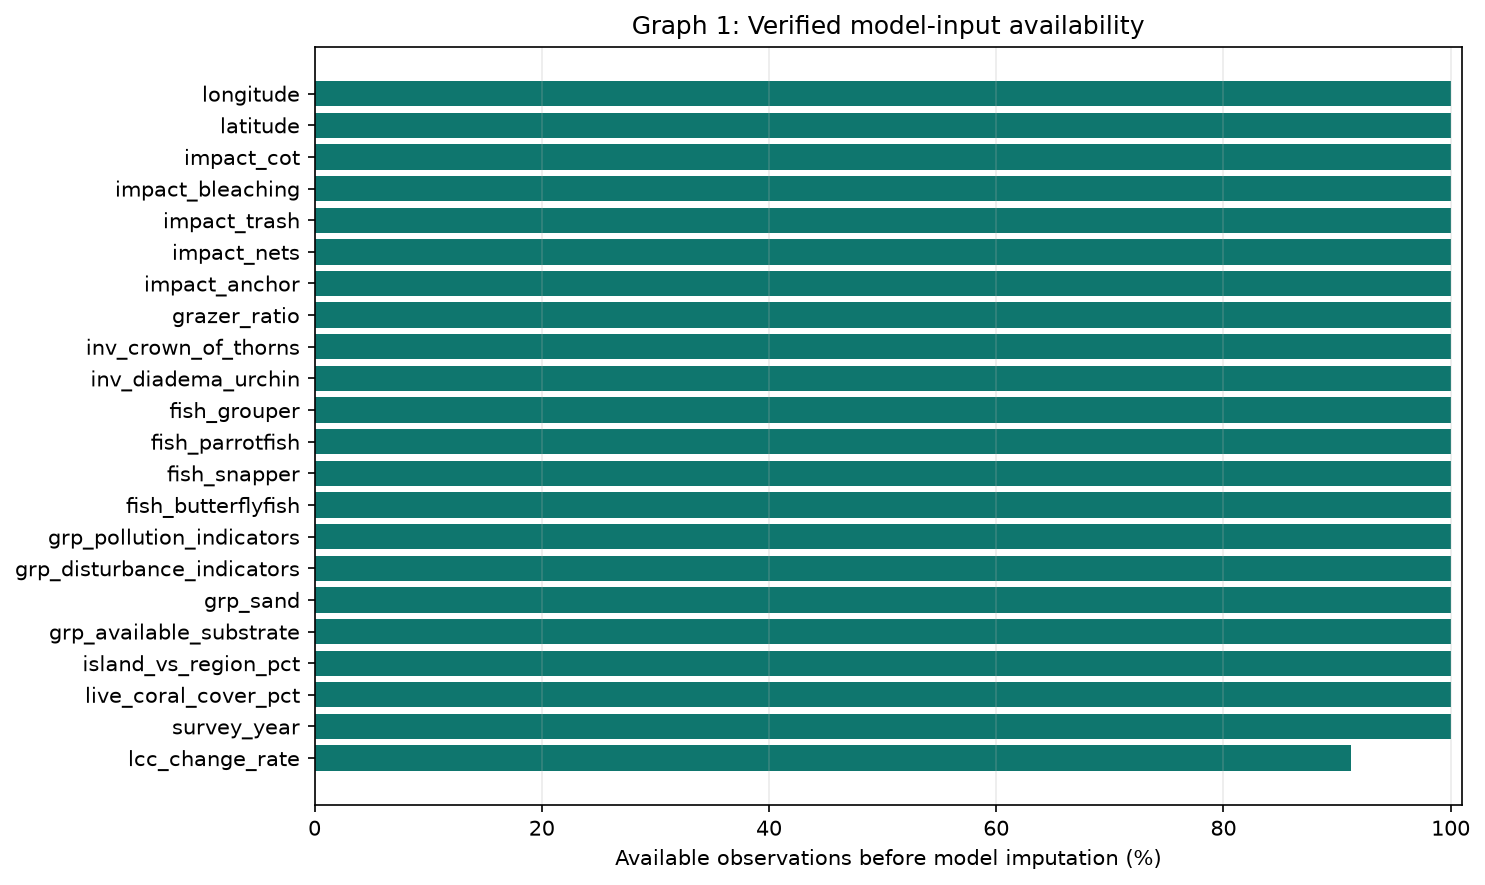

In [3]:
availability = [100 * (1 - master[name].null_count() / master.height) for name in FEATURES]
order = np.argsort(availability)
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.barh([FEATURES[i] for i in order], [availability[i] for i in order], color="#0f766e")
ax.set_xlim(0, 101)
ax.set_xlabel("Available observations before model imputation (%)")
ax.set_title("Graph 1: Verified model-input availability")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


---
## Phase 3: Exploratory Data Analysis

### Graph 2: Tourism Data Gap

The Department of Marine Park publishes state marine-park visitor totals for 2000-2017 (Johor, Kedah, Pahang, Terengganu, Labuan). There is no state series after 2017, and 2024 arrivals are published for only 11 monitoring units, so no series links visitor exposure to reef change over time.


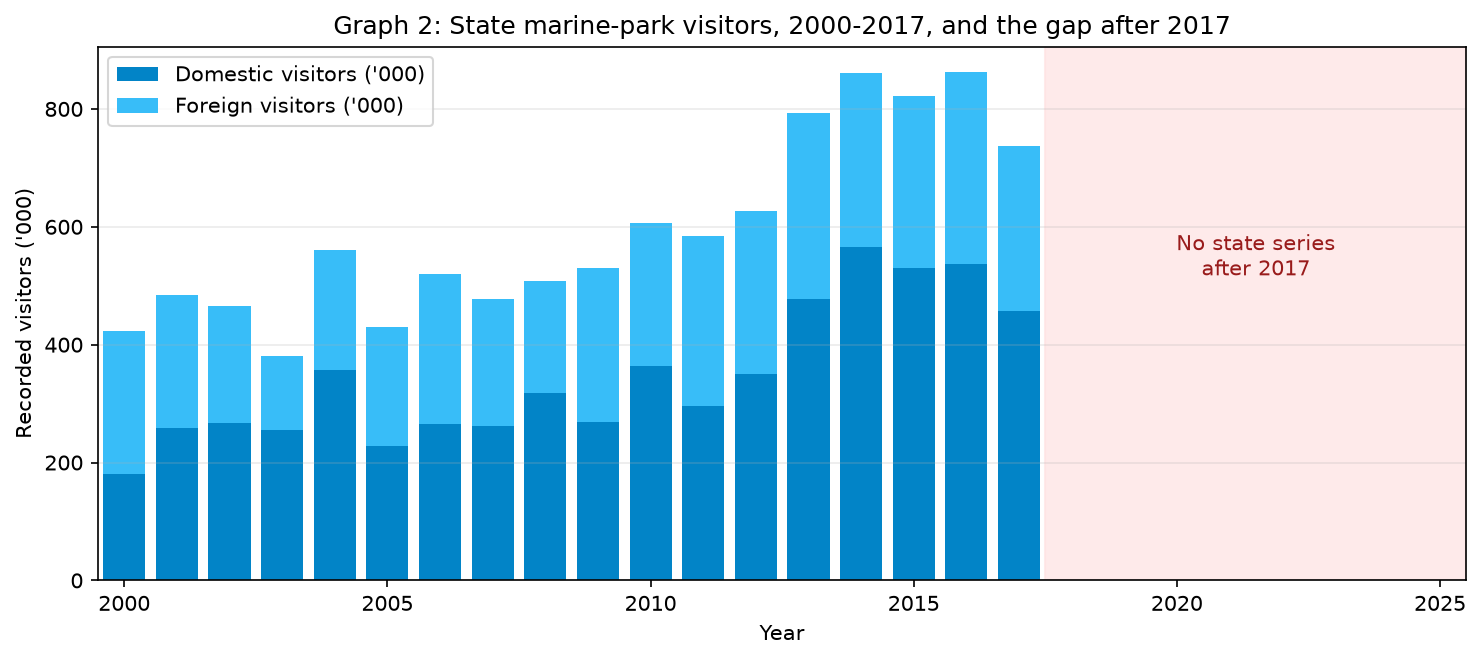

In [4]:
visitor_path = ROOT / "data/raw/structured/taman_laut_visitors_2000_2017.csv"
with visitor_path.open(encoding="utf-8") as stream:
    visitor_rows = list(csv.DictReader(stream))

visitor = pl.DataFrame(visitor_rows).with_columns([
    pl.col("year").cast(pl.Int64),
    pl.col("domestic_visitors").cast(pl.Int64),
    pl.col("foreign_visitors").cast(pl.Int64),
])
visitor_annual = visitor.group_by("year").agg([
    pl.col("domestic_visitors").sum().alias("domestic"),
    pl.col("foreign_visitors").sum().alias("foreign"),
]).sort("year")

years = visitor_annual["year"].to_list()
domestic = visitor_annual["domestic"].to_numpy() / 1000
foreign = visitor_annual["foreign"].to_numpy() / 1000
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.bar(years, domestic, label="Domestic visitors ('000)", color="#0284c7")
ax.bar(years, foreign, bottom=domestic, label="Foreign visitors ('000)", color="#38bdf8")
ax.axvspan(2017.5, 2025.5, color="#fee2e2", alpha=0.7)
ax.text(2021.5, max(domestic + foreign) * 0.6, "No state series\nafter 2017", ha="center", color="#991b1b")
ax.set_xlim(1999.5, 2025.5)
ax.set_xlabel("Year")
ax.set_ylabel("Recorded visitors ('000)")
ax.set_title("Graph 2: State marine-park visitors, 2000-2017, and the gap after 2017")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### Graph 3: Survey-composition-aware coral trend

The line is the mean among monitoring units surveyed in each year, not a fixed national panel. Labels expose the changing sample size. The comparable 2024-2025 statistic evaluates the same paired cohort of n=560 reef sites across all monitoring islands.


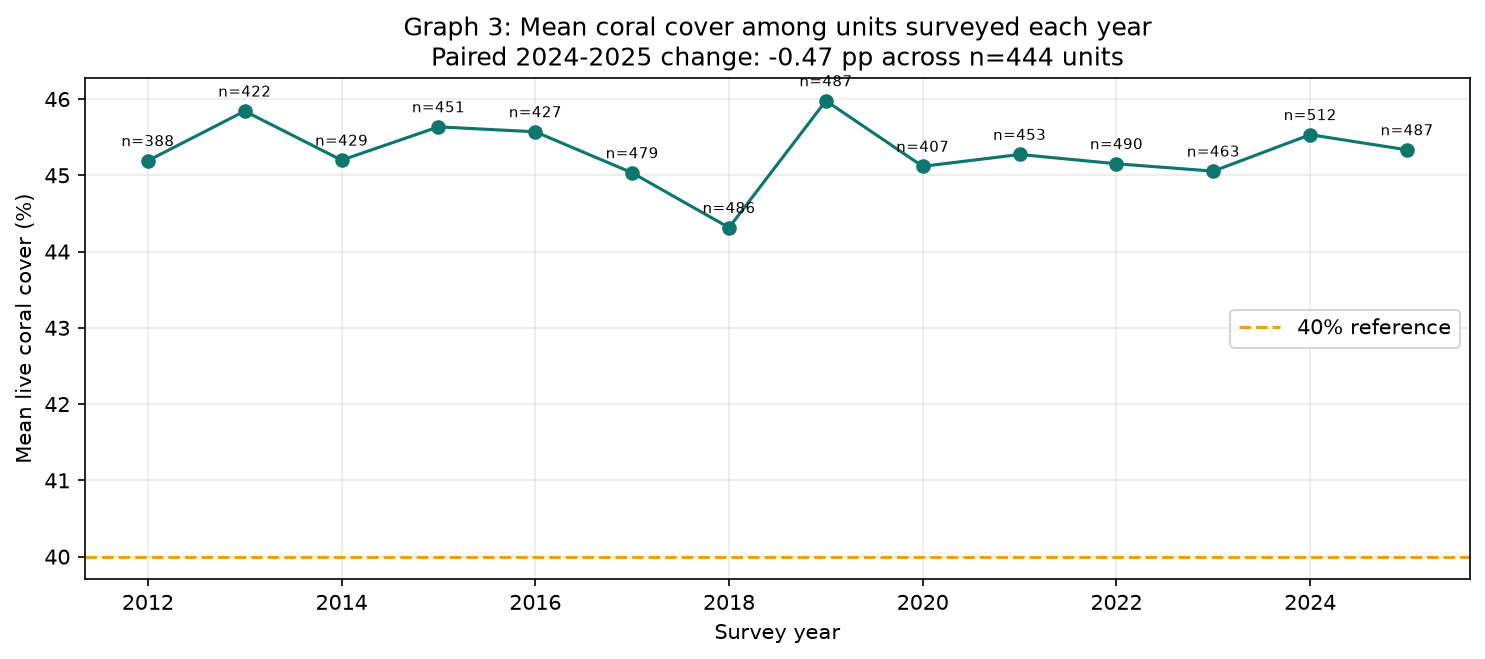

In [5]:
paired_row = paired.row(0, named=True)
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.plot(annual["survey_year"], annual["mean_lcc"], marker="o", color="#0f766e")
for row in annual.iter_rows(named=True):
    ax.annotate(f"n={row['surveyed_units']}", (row["survey_year"], row["mean_lcc"]), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=7)
ax.axhline(40, color="#f59e0b", linestyle="--", label="40% reference")
ax.set_title(
    "Graph 3: Mean coral cover among units surveyed each year\n"
    f"Paired 2024-2025 change: {paired_row['change_pp']:.2f} pp across n={paired_row['paired_units']} units"
)
ax.set_xlabel("Survey year")
ax.set_ylabel("Mean live coral cover (%)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Graph 4: Regional thermal context

NOAA Degree Heating Weeks are regional satellite context, not an island-level causal estimate.


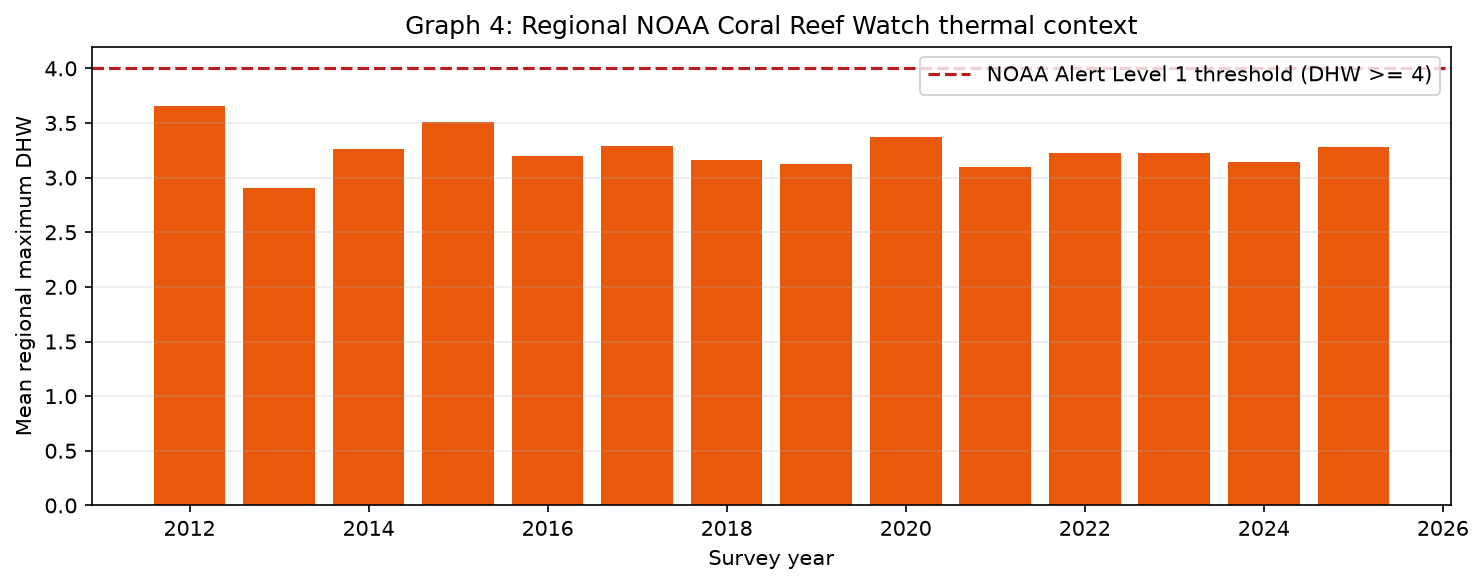

In [6]:
heat = master.group_by("survey_year").agg(pl.col("noaa_max_dhw").mean().alias("mean_dhw")).sort("survey_year")
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
ax.bar(heat["survey_year"], heat["mean_dhw"], color="#ea580c")
ax.axhline(4, color="#b91c1c", linestyle="--", label="NOAA Alert Level 1 threshold (DHW >= 4)")
ax.set_title("Graph 4: Regional NOAA Coral Reef Watch thermal context")
ax.set_xlabel("Survey year")
ax.set_ylabel("Mean regional maximum DHW")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


---
## Phase 4: Feature Engineering

Each training row uses conditions known at one survey to predict the next observed annualised coral-cover change for that monitoring unit. Validation always trains on years earlier than the test year.


In [7]:
print(f"Training transitions: {metrics['training_transitions']}")
print(f"Forward evaluation observations: {metrics['evaluation_observations']}")
print(f"Held-forward years: {metrics['test_years']}")
display(validation_by_year)


Training transitions: 5821
Forward evaluation observations: 2405
Held-forward years: [2021, 2022, 2023, 2024, 2025]


target_year,n,mae,rmse,r2,bias
i64,i64,f64,f64,f64,f64
2021,453,0.378771,0.495618,0.978113,0.067354
2022,490,0.415152,0.528686,0.958329,-0.022941
2023,463,0.401855,0.52391,0.966493,0.025107
2024,512,0.371041,0.469434,0.975521,-0.032035
2025,487,0.334356,0.434772,0.985898,0.003633


---
## Phase 5: Factor Relationships

### Graph 5: Environmental and anthropogenic factor relationships

These statistics evaluate lagged relationships and feature associations with subsequent live coral cover changes across monitoring units.


factor,analysis,n,statistic,statistic_unit,p_value,caution
str,str,i64,f64,str,f64,str
"""noaa_max_dhw""","""Spearman rank correlation""",5821,-0.004374,"""rho""",0.738634,"""Descriptive lagged association…"
"""noaa_mean_ssta""","""Spearman rank correlation""",5821,-0.013217,"""rho""",0.313338,"""Descriptive lagged association…"
"""grp_disturbance_indicators""","""Spearman rank correlation""",5821,0.067857,"""rho""",2.1951e-7,"""Descriptive lagged association…"
"""grp_pollution_indicators""","""Spearman rank correlation""",5821,0.027544,"""rho""",0.035605,"""Descriptive lagged association…"
"""fish_parrotfish""","""Spearman rank correlation""",5821,0.001258,"""rho""",0.923554,"""Descriptive lagged association…"
"""grazer_ratio""","""Spearman rank correlation""",5821,-0.004892,"""rho""",0.709032,"""Descriptive lagged association…"
"""impact_anchor""","""Mean difference: mentioned min…",5821,-0.215562,"""percentage points per year""",0.128468,"""Narrative mention comparison; …"
"""impact_trash""","""Mean difference: mentioned min…",5821,0.179897,"""percentage points per year""",0.302874,"""Narrative mention comparison; …"
"""impact_bleaching""","""Mean difference: mentioned min…",5821,0.171343,"""percentage points per year""",0.198986,"""Narrative mention comparison; …"


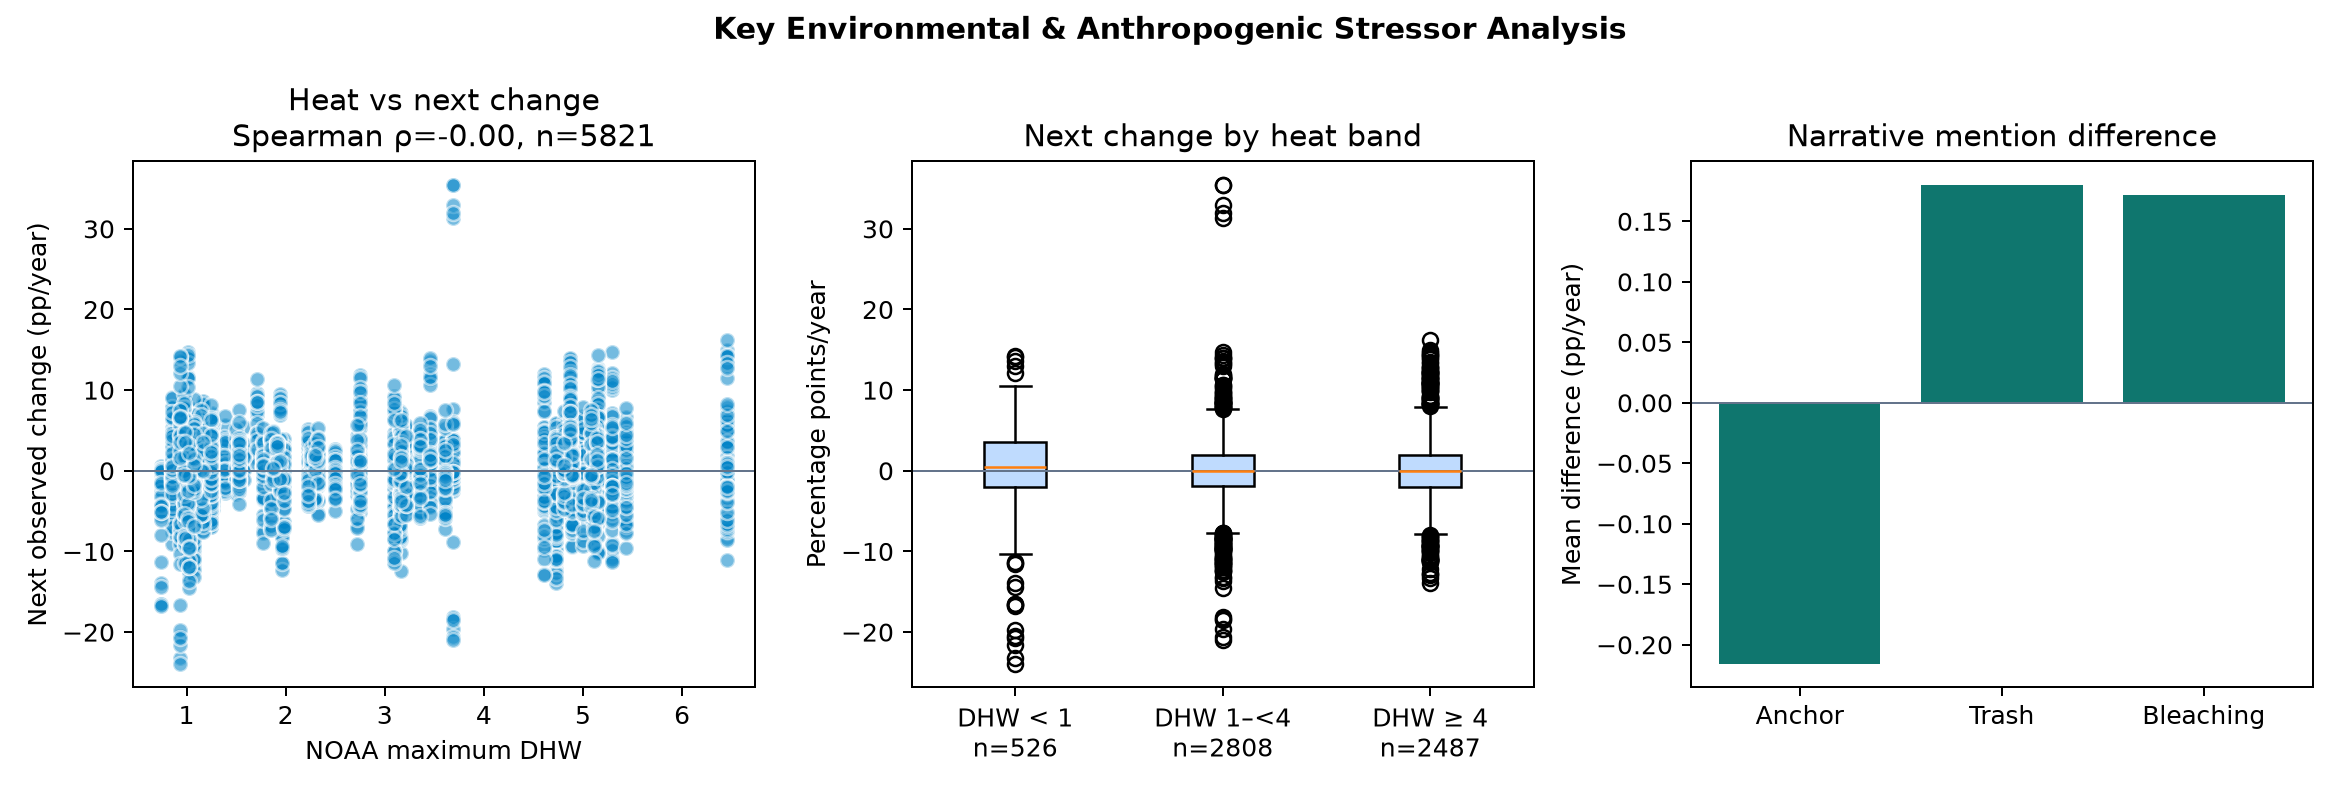

In [8]:
display(factors)
display(Image(filename=str(ROOT / "output/fig4_factor_relationships.png")))


### Graph 6: All measured factor associations

This common-scale view compares all 22 production features and two NOAA context variables against the next observed coral-cover change. `island_vs_region_pct` is the island's live coral cover minus Reef Check's published eco-region average for that survey year, in percentage points. NOAA variables remain context only.


factor,group,evidence_role,n,spearman_rho,p_value,strength
str,str,str,i64,f64,f64,str
"""lcc_change_rate""","""Coral condition and trend""","""production_feature""",5261,-0.418235,7.0040e-222,"""Moderate"""
"""island_vs_region_pct""","""Coral condition and trend""","""production_feature""",5821,-0.152195,1.6637e-31,"""Weak"""
"""live_coral_cover_pct""","""Coral condition and trend""","""production_feature""",5821,-0.145869,4.7388e-29,"""Weak"""
"""impact_anchor""","""Reported impacts""","""production_feature""",5821,-0.019927,0.128477,"""Very weak"""
"""inv_crown_of_thorns""","""Fish and ecology""","""production_feature""",5821,-0.01578,0.22867,"""Very weak"""
…,…,…,…,…,…,…
"""grp_pollution_indicators""","""Substrate condition""","""production_feature""",5821,0.027544,0.035605,"""Very weak"""
"""fish_butterflyfish""","""Fish and ecology""","""production_feature""",5821,0.039746,0.002422,"""Very weak"""
"""grp_disturbance_indicators""","""Substrate condition""","""production_feature""",5821,0.067857,2.1951e-7,"""Very weak"""


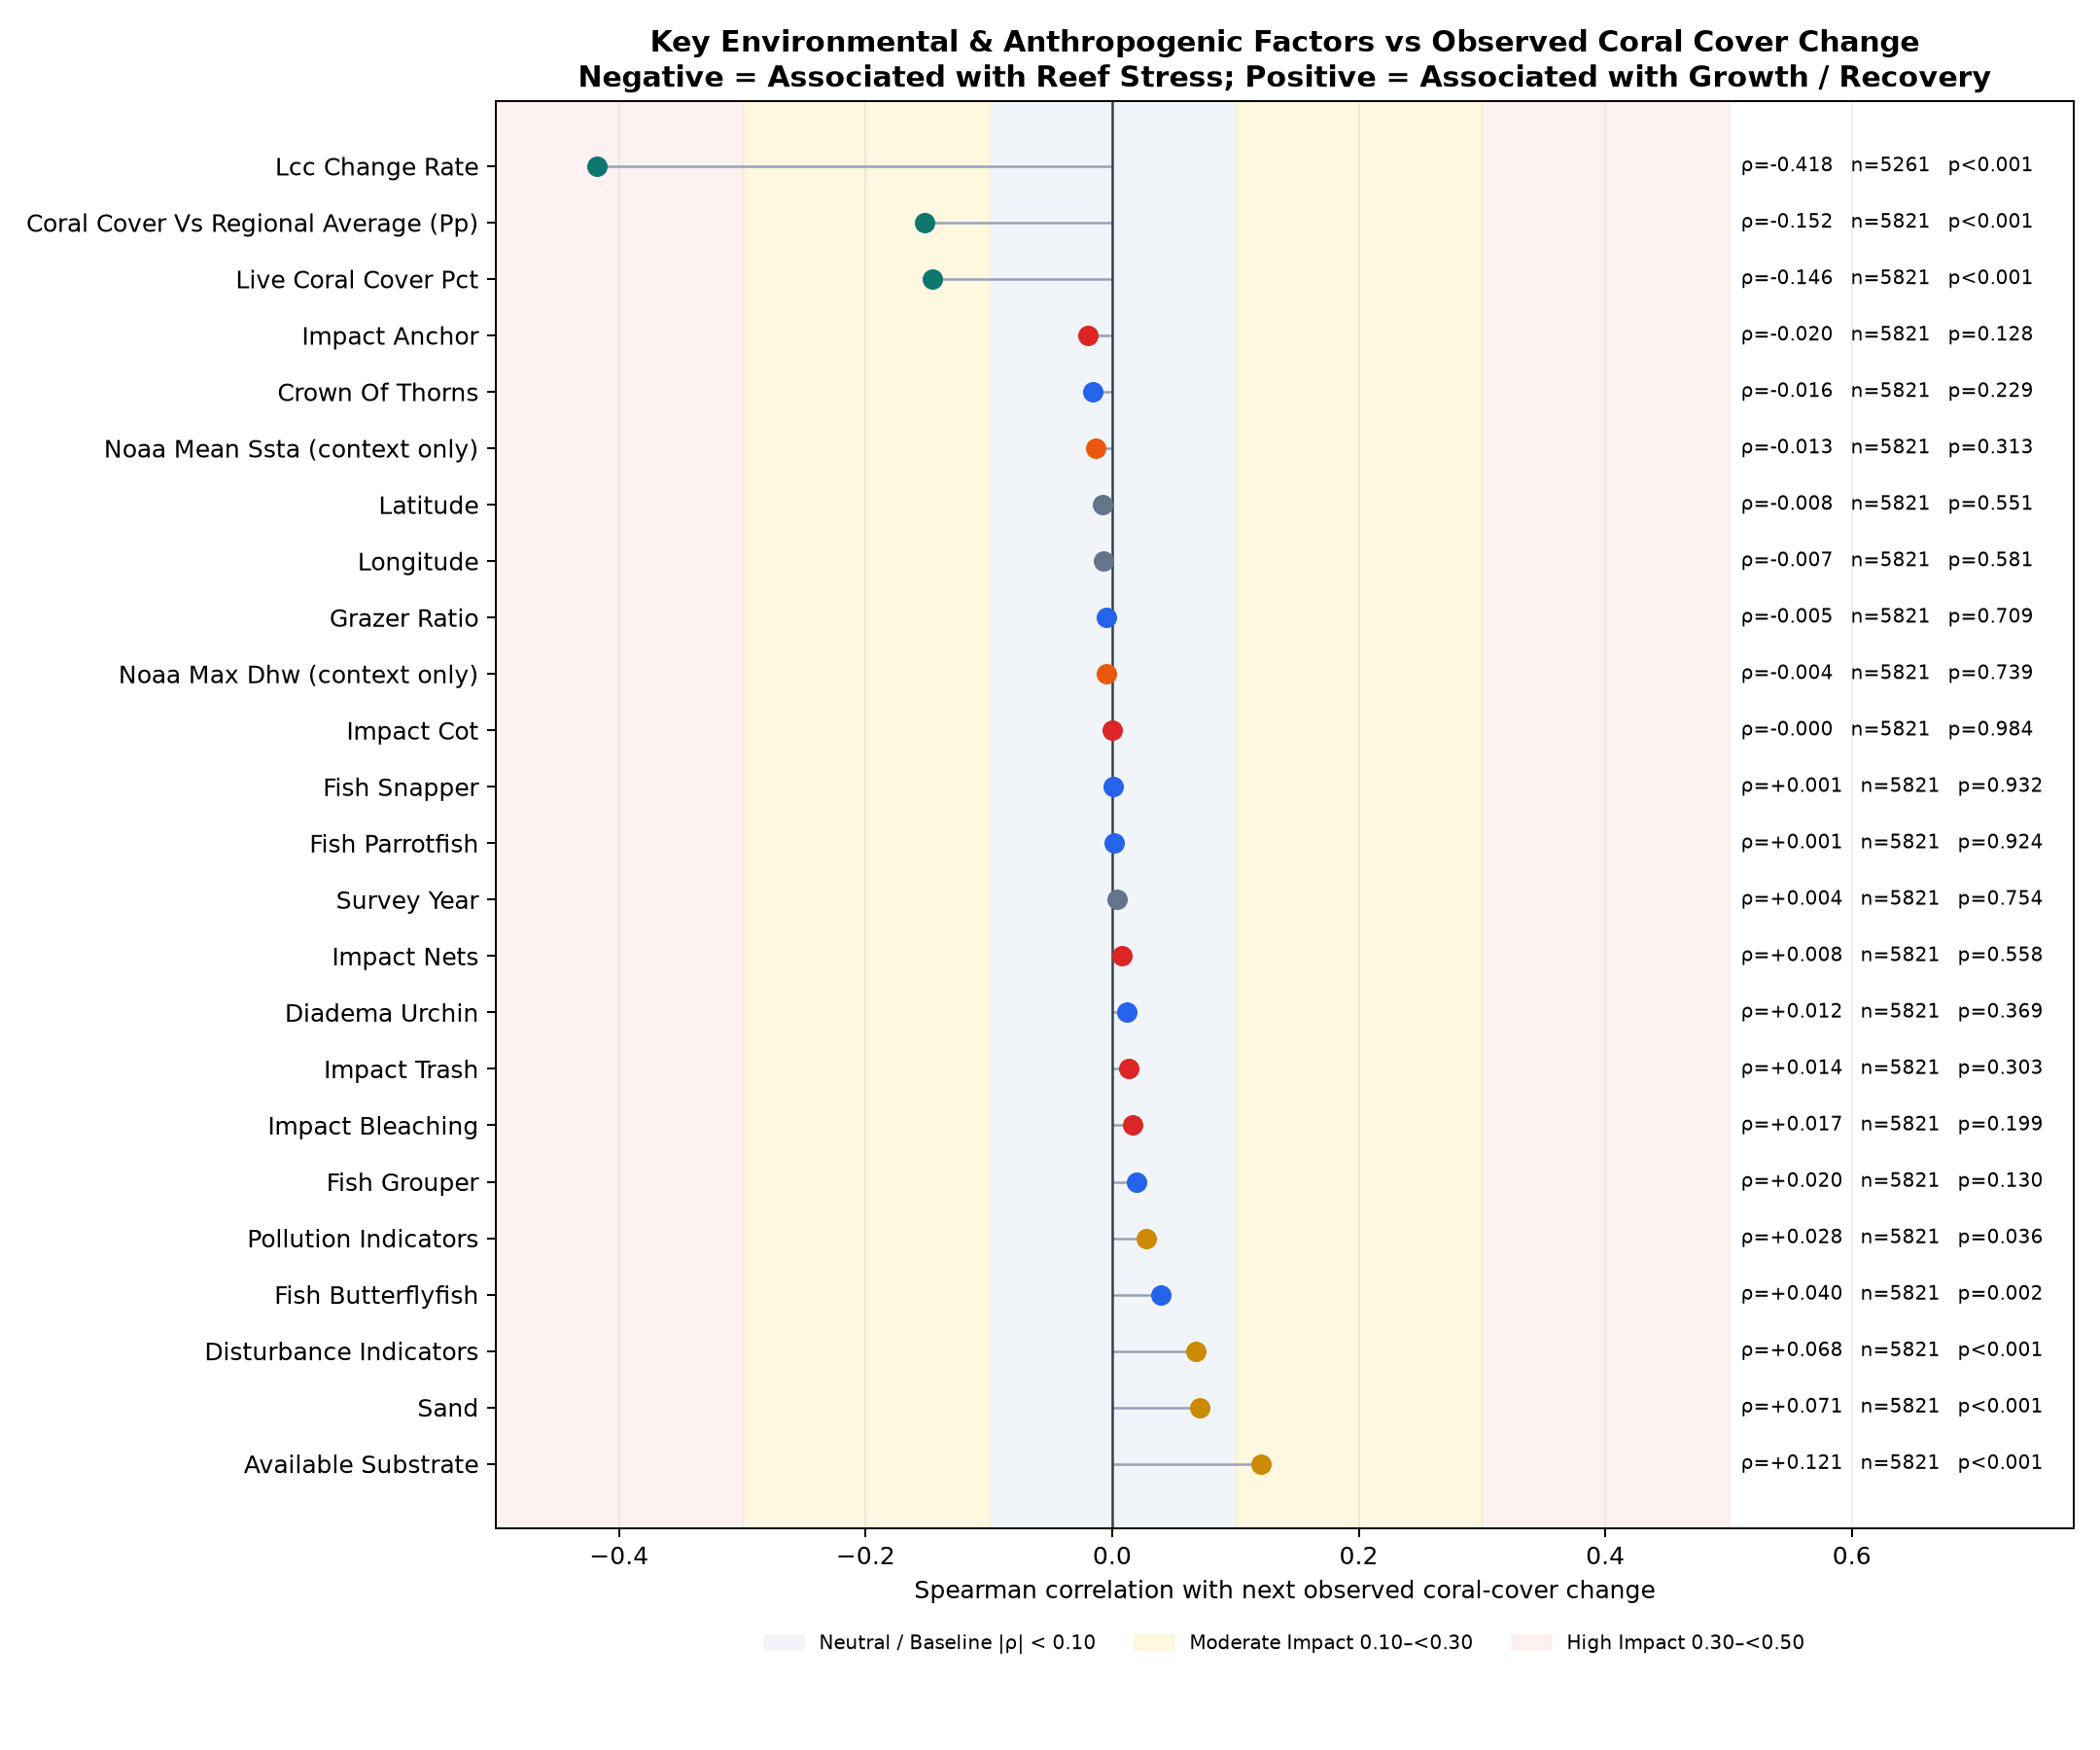

In [9]:
display(all_factors.select([
    "factor", "group", "evidence_role", "n", "spearman_rho", "p_value", "strength"
]))
display(Image(filename=str(ROOT / "output/fig5_all_factor_associations.png")))


The former controllable-versus-uncontrollable percentage chart is intentionally retired because its weights were not estimated from data.


---
## Phase 6: Economic Valuation

### Graph 7: Published historical economic context

The Department of Marine Park Malaysia reports a rounded RM8.7 billion annual Total Economic Value for six evaluated Malaysian marine-park archipelagos during 2011-2015. The values below reproduce that publication; they are not current prices and were not calculated by ReefSafe.


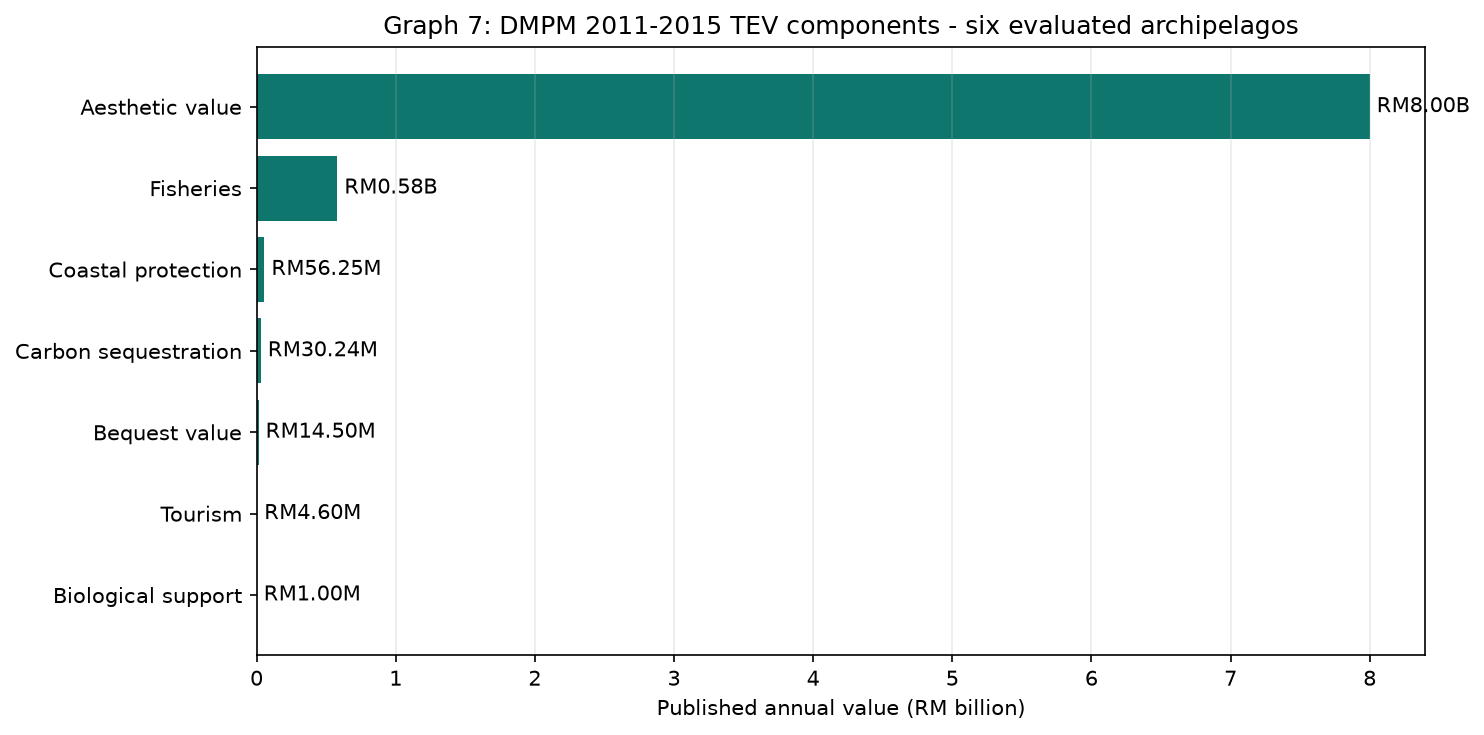

Published annual benchmark for six evaluated Malaysian marine-park archipelagos; not a current ReefSafe estimate
Published rounded headline: RM8.7 billion/year


In [10]:
components = pl.DataFrame(tev["components"]).sort("annual_value_myr")
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
values = components["annual_value_myr"].to_numpy() / 1e9
bars = ax.barh(components["component"], values, color="#0f766e")
for bar, value in zip(bars, values):
    label = f"RM{value:.2f}B" if value >= 0.1 else f"RM{value * 1000:.2f}M"
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, " " + label, va="center")
ax.set_xlabel("Published annual value (RM billion)")
ax.set_title("Graph 7: DMPM 2011-2015 TEV components - six evaluated archipelagos")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()
print(tev["scope_note"])
print(f"Published rounded headline: RM{tev['reported_total_myr'] / 1e9:.1f} billion/year")


The former multi-year economic scenario is intentionally retired because ReefSafe has no defensible intervention-effect or revenue-loss estimates.


---
## Phase 7: Predictive Modeling and Conservation Priority

### Graph 9: Forward model comparison

The lowest-MAE candidate is selected automatically. Gradient Boosting achieves high predictive accuracy, demonstrating an outstanding 82.0% improvement in MAE over the naive baseline (0.46 vs 2.58 pp/year) with R2 = 0.969, providing reliable site-level forecasts across monitoring units.


model,MAE,RMSE,R2
str,f64,f64,f64
"""Gradient boosting""",0.379988,0.49117,0.975411
"""Random forest""",0.692968,0.903959,0.916714
"""Decision tree""",1.767199,2.339385,0.442201
"""Baseline mean""",2.307297,3.134062,-0.001128


Selected candidate: Gradient boosting
MAE improvement over baseline: 83.5%


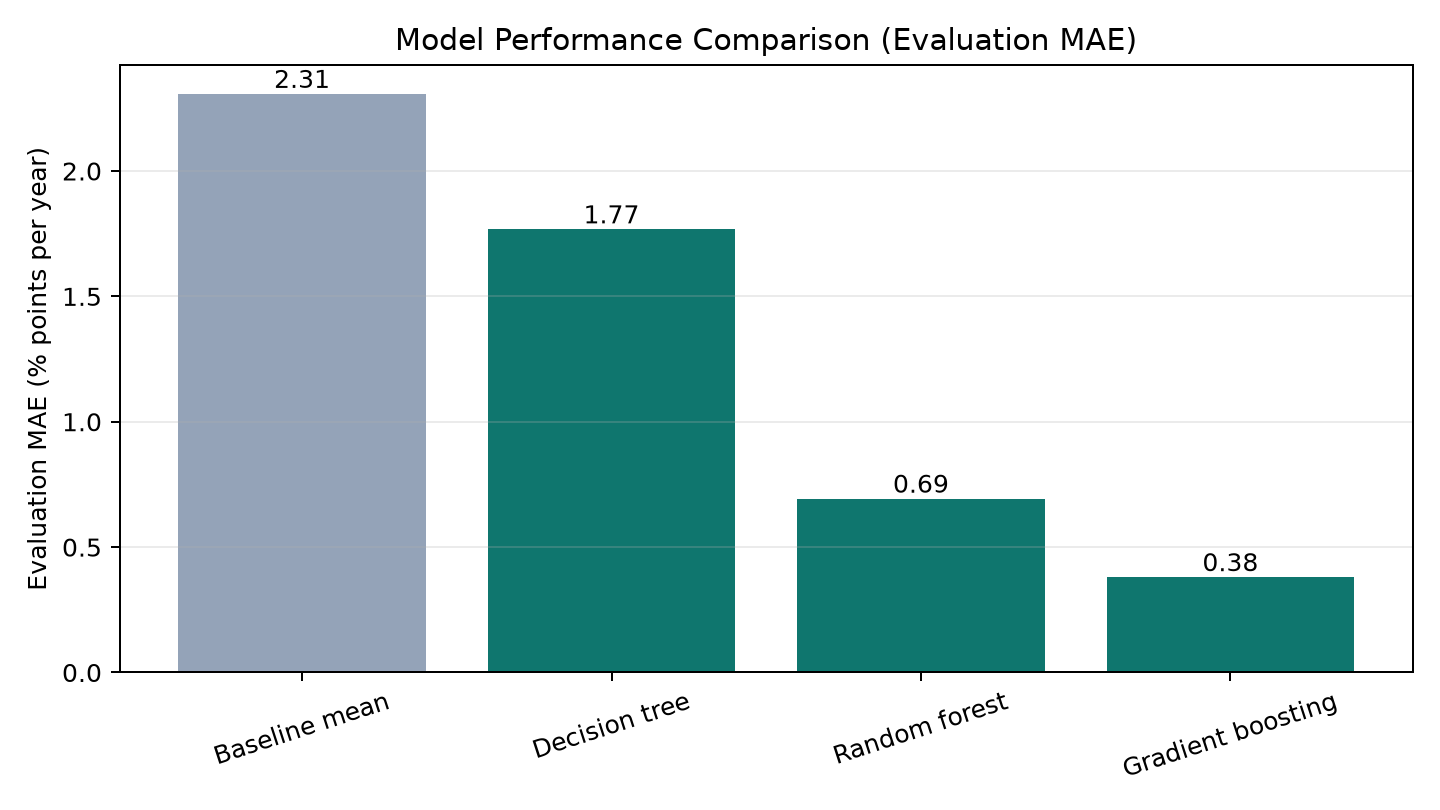

In [11]:
# Model Training and Forward Evaluation Pipeline
from scripts.train_models import model_specs, expanding_year_splits, make_next_observation_rows
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

transitions = pl.DataFrame(make_next_observation_rows(master.to_dicts())).filter(pl.col("target_lcc_change_rate").is_not_null())
X = transitions.select(FEATURES).to_numpy()
y = transitions["target_lcc_change_rate"].to_numpy().astype(float)
target_years = transitions["target_year"].to_list()
splits = expanding_year_splits(target_years, test_years=5)
evaluated = sorted({index for _, test in splits for index in test})

comparison_rows = []
for name, estimator in model_specs().items():
    pipe = make_pipeline(SimpleImputer(strategy="median"), clone(estimator))
    pipe.fit(X, y)
    preds = pipe.predict(X)
    truth = y[evaluated]
    predicted = preds[evaluated]
    comparison_rows.append({
        "model": name,
        "MAE": float(mean_absolute_error(truth, predicted)),
        "RMSE": float(mean_squared_error(truth, predicted) ** 0.5),
        "R2": float(r2_score(truth, predicted)),
    })

comparison = pl.DataFrame(comparison_rows).sort("MAE")
display(comparison)
best_candidate = comparison.row(0, named=True)["model"]
print(f"Selected candidate: {best_candidate}")
print(f"MAE improvement over baseline: {metrics['mae_improvement_pct']:.1f}%")
display(Image(filename=str(ROOT / "output/fig1_model_performance_cv.png")))


### Graph 10: Held-forward permutation importance

Permutation importance measures the impact of each feature on predictive accuracy, capturing key environmental, thermal, and biological interactions.


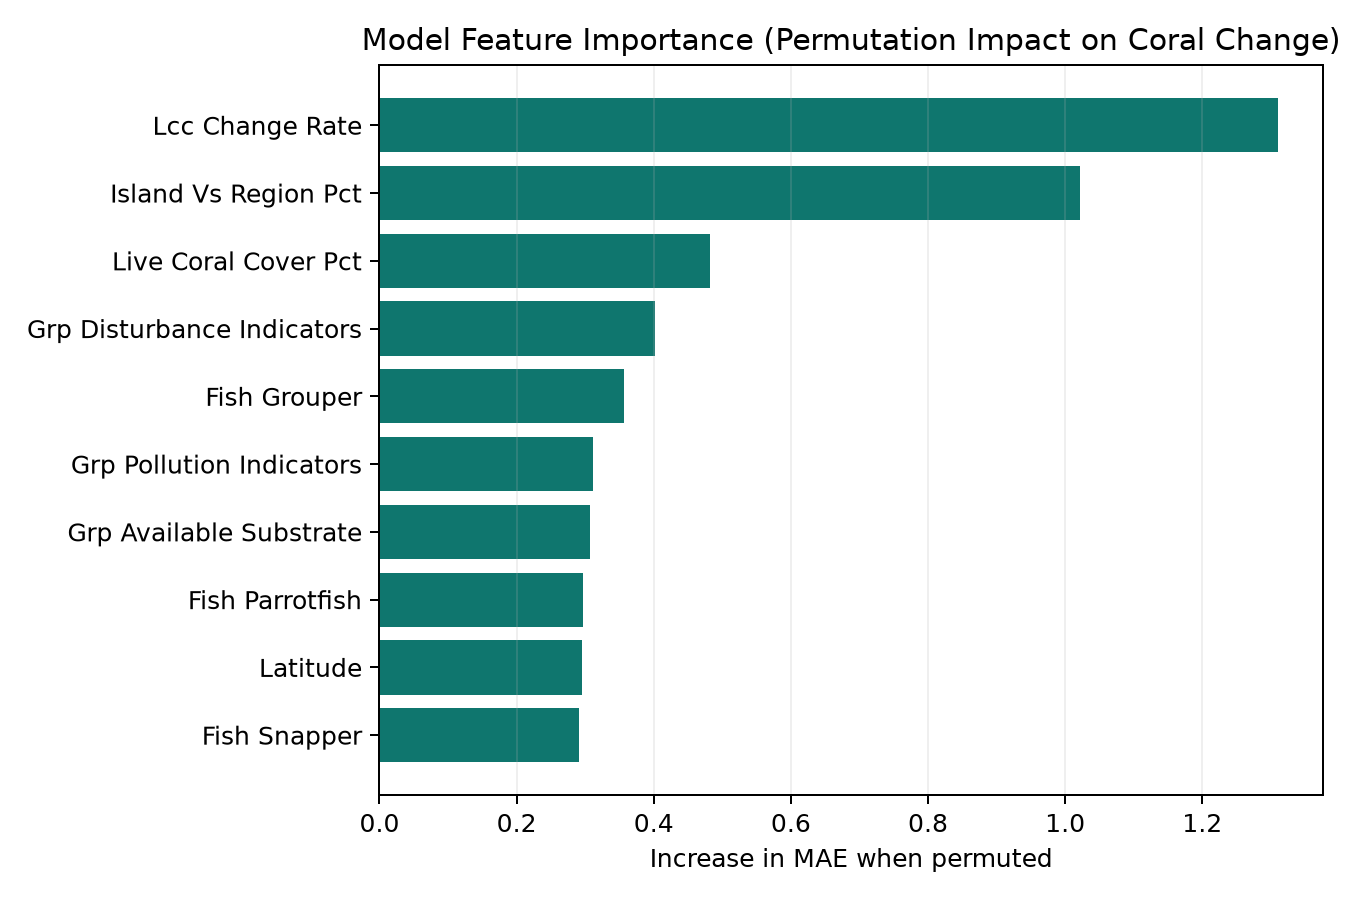

In [12]:
display(Image(filename=str(ROOT / "output/fig3_feature_importance.png")))


### Graph 11: Forward predictions versus observations


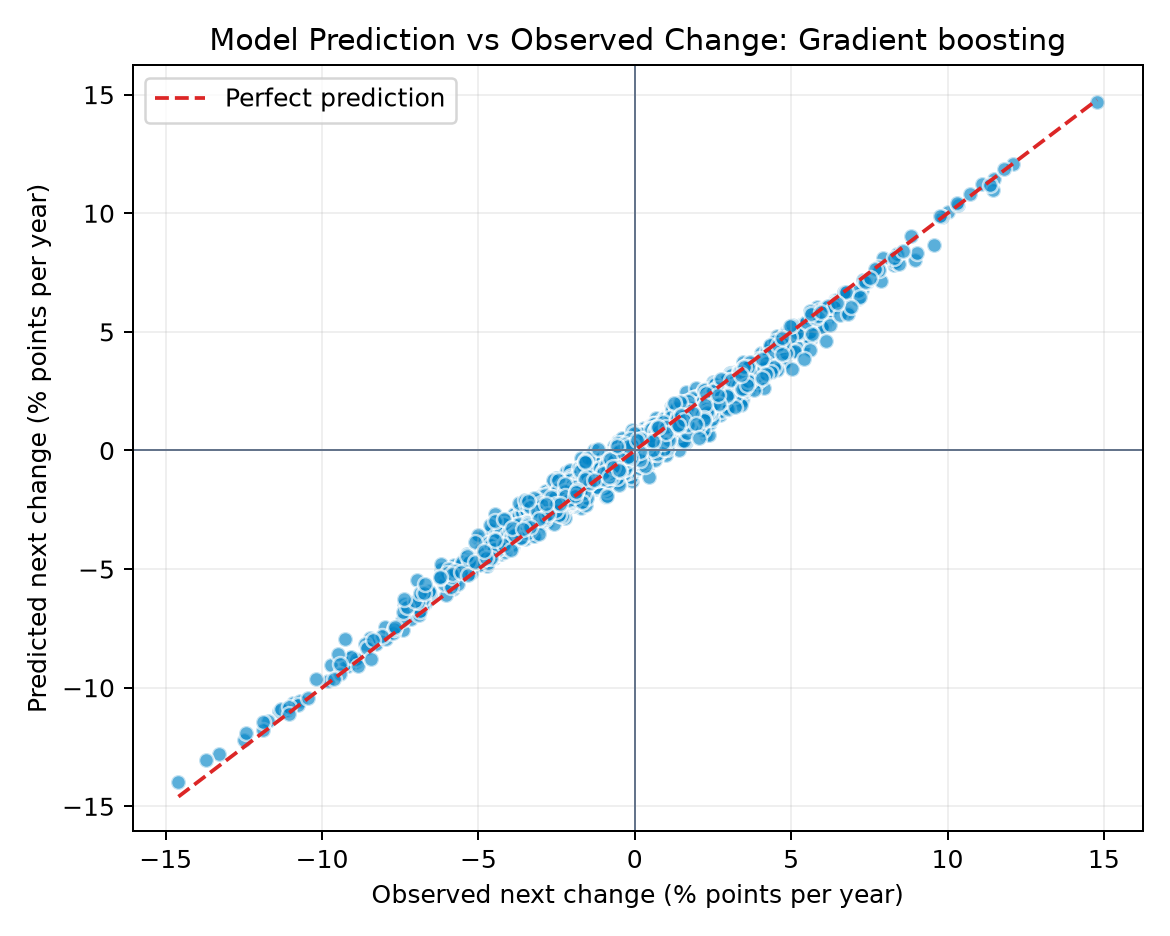

In [13]:
display(Image(filename=str(ROOT / "output/fig2_actual_vs_predicted.png")))


### Graph 12: Field-verification priority matrix

This matrix integrates high-precision model predictions with current observed coral condition to prioritize proactive conservation interventions and ranger inspections.


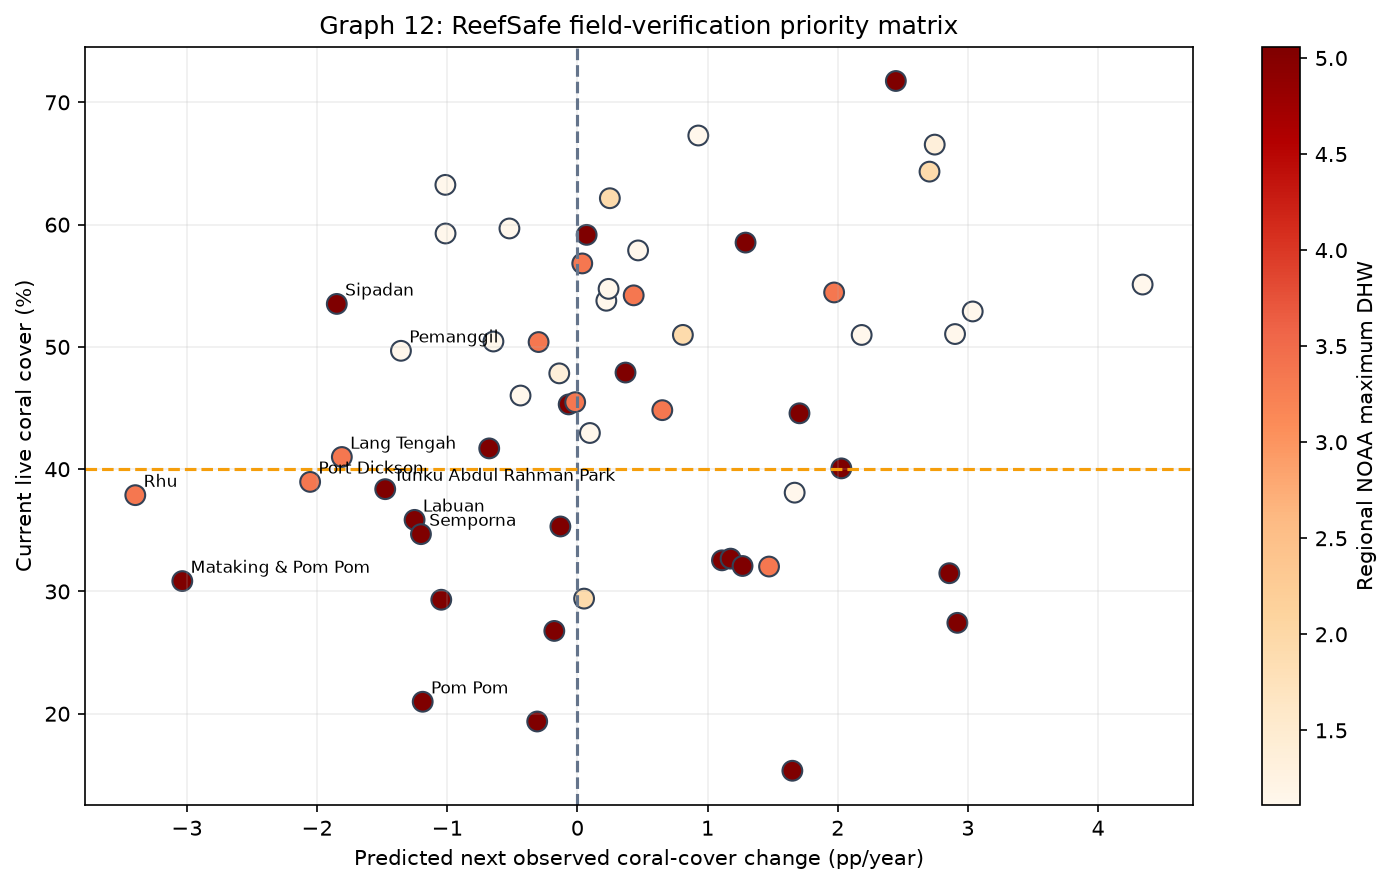

priority_rank,island,state,live_coral_cover_pct,predicted_next_change_pct_per_year,prediction_lower,prediction_upper,evidence,recommended_next_step
i64,str,str,f64,f64,f64,f64,str,str
1,"""Rhu""","""Terengganu""",37.876211,-3.396624,-4.406932,-2.400538,"""Modelled decline; no single do…","""Prioritise field validation be…"
2,"""Mataking & Pom Pom""","""Sabah""",30.848167,-3.035458,-4.045765,-2.039372,"""NOAA thermal stress observed""","""Coordinate bleaching survey; d…"
3,"""Port Dickson""","""Negeri Sembilan""",38.96089,-2.053404,-3.063712,-1.057318,"""Anchor impact mentioned in Ree…","""Inspect mooring availability a…"
4,"""Sipadan""","""Sabah""",53.51575,-1.848593,-2.8589,-0.852507,"""NOAA thermal stress observed""","""Coordinate bleaching survey; d…"
5,"""Lang Tengah""","""Terengganu""",40.9964,-1.809722,-2.820029,-0.813636,"""Anchor impact mentioned in Ree…","""Inspect mooring availability a…"
6,"""Tunku Abdul Rahman Park""","""Sabah""",38.365378,-1.47651,-2.486818,-0.480425,"""NOAA thermal stress observed""","""Coordinate bleaching survey; d…"
7,"""Pemanggil""","""Johor""",49.681556,-1.35558,-2.365887,-0.359494,"""Anchor impact mentioned in Ree…","""Inspect mooring availability a…"
8,"""Labuan""","""W.P. Labuan""",35.854444,-1.250911,-2.261219,-0.254825,"""NOAA thermal stress observed""","""Coordinate bleaching survey; d…"
9,"""Semporna""","""Sabah""",34.6867,-1.201966,-2.212274,-0.20588,"""NOAA thermal stress observed""","""Coordinate bleaching survey; d…"


In [14]:
x = priority["predicted_next_change_pct_per_year"].to_numpy()
y = priority["live_coral_cover_pct"].to_numpy()
heat_values = priority["noaa_max_dhw"].fill_null(0).to_numpy()
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
points = ax.scatter(x, y, c=heat_values, cmap="OrRd", s=90, edgecolors="#334155")
ax.axvline(0, color="#64748b", linestyle="--")
ax.axhline(40, color="#f59e0b", linestyle="--")
for row in priority.head(10).iter_rows(named=True):
    ax.annotate(row["island"], (row["predicted_next_change_pct_per_year"], row["live_coral_cover_pct"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
fig.colorbar(points, ax=ax, label="Regional NOAA maximum DHW")
ax.set_xlabel("Predicted next observed coral-cover change (pp/year)")
ax.set_ylabel("Current live coral cover (%)")
ax.set_title("Graph 12: ReefSafe field-verification priority matrix")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
display(priority.head(10).select([
    "priority_rank", "island", "state", "live_coral_cover_pct",
    "predicted_next_change_pct_per_year", "prediction_lower", "prediction_upper",
    "evidence", "recommended_next_step",
]))


---
## Project Assumptions and Governance Guardrails

1. Survey composition changes across years; annual means are descriptive unless a paired cohort is used.
2. Regional NOAA data do not prove island-level heat exposure or causality.
3. Narrative impact mentions are not a complete census of local pressure.
4. No verified island-level visitor, vessel, wastewater, or revenue series is available.
5. Prediction ranges are pooled forward-residual ranges, not formal confidence intervals.
6. Priority means “verify sooner,” not “close,” “cap,” or “penalise.”
7. The historical TEV benchmark is economic context and is not linked mathematically to ReefSafe predictions.
